In [4]:
import pandas as pd

data = pd.read_csv('data_choice_complete.csv')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45211 non-null  float64
 1   job        45211 non-null  float64
 2   marital    45211 non-null  float64
 3   education  45211 non-null  float64
 4   balance    45211 non-null  float64
 5   housing    45211 non-null  float64
 6   loan       45211 non-null  float64
 7   month      45211 non-null  float64
 8   duration   45211 non-null  float64
 9   campaign   45211 non-null  float64
 10  y          45211 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 3.8 MB


In [5]:
from sklearn.model_selection import train_test_split

X=data.drop('y', axis=1)
y=data['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((36168, 10), (9043, 10), (36168,), (9043,))

In [ ]:
# 模型訓練與比較

## 1. Logistic Regression (邏輯迴歸)

/var/folders/b_/7l5pfh497cb4pvygfn49ll_40000gn/T/ipykernel_3454/340170720.py:32: UserWarning: Glyph 28310 (\N{CJK UNIFIED IDEOGRAPH-6E96}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/b_/7l5pfh497cb4pvygfn49ll_40000gn/T/ipykernel_3454/340170720.py:32: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/b_/7l5pfh497cb4pvygfn49ll_40000gn/T/ipykernel_3454/340170720.py:32: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/b_/7l5pfh497cb4pvygfn49ll_40000gn/T/ipykernel_3454/340170720.py:32: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/b_/7l5pfh497cb4pvygfn49ll_40000gn/T/ipykernel_3454/340170720.py:32: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/b_/7l5pfh497cb4pv

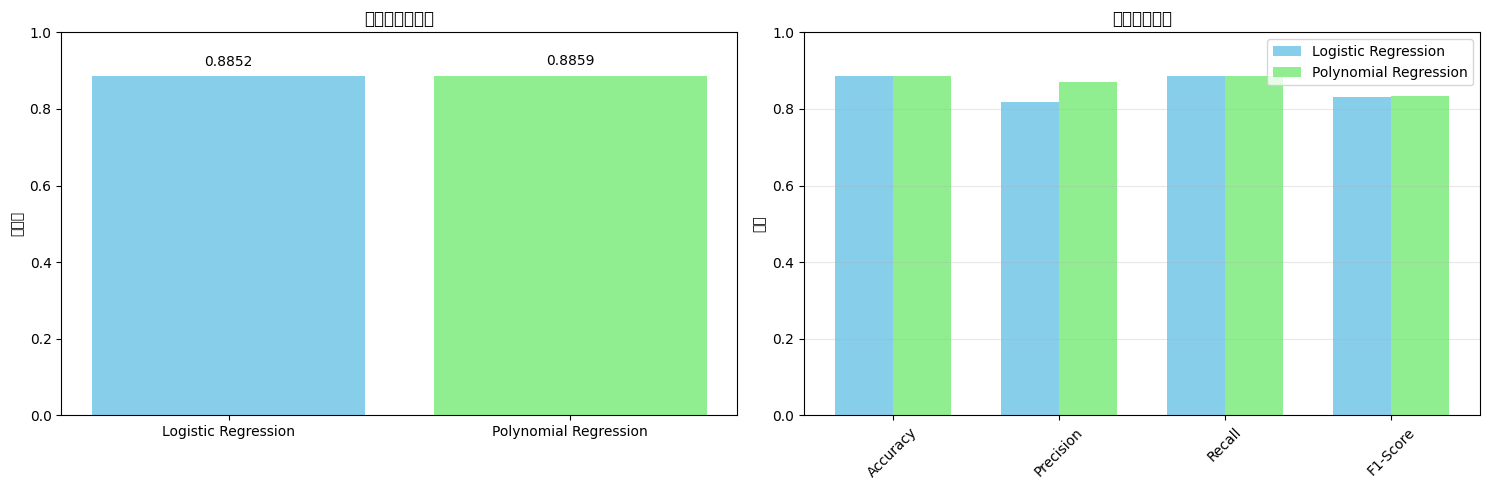

In [11]:
# 視覺化比較
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. 準確率比較長條圖
axes[0].bar(results_df['Model'], results_df['Accuracy'], color=['skyblue', 'lightgreen'])
axes[0].set_ylabel('準確率')
axes[0].set_title('模型準確率比較')
axes[0].set_ylim([0, 1])
for i, v in enumerate(results_df['Accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom')

# 2. 各項指標雷達圖比較
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = range(len(metrics))
width = 0.35

axes[1].bar([i - width/2 for i in x], 
           [results_df.loc[0, m] for m in metrics], 
           width, label='Logistic Regression', color='skyblue')
axes[1].bar([i + width/2 for i in x], 
           [results_df.loc[1, m] for m in metrics], 
           width, label='Polynomial Regression', color='lightgreen')

axes[1].set_ylabel('分數')
axes[1].set_title('各項指標比較')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, rotation=45)
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score

# 計算各項指標
results = {
    'Model': ['Logistic Regression', 'Polynomial Regression'],
    'Accuracy': [log_acc, poly_acc],
    'Precision': [
        precision_score(y_test, y_pred_log, average='weighted'),
        precision_score(y_test, y_pred_poly, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred_log, average='weighted'),
        recall_score(y_test, y_pred_poly, average='weighted')
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_log, average='weighted'),
        f1_score(y_test, y_pred_poly, average='weighted')
    ]
}

# 建立比較表格
results_df = pd.DataFrame(results)
print("模型效能比較表:")
print(results_df.to_string(index=False))
print("\n" + "="*60)
print(f"最佳模型: {results_df.loc[results_df['Accuracy'].idxmax(), 'Model']}")
print(f"最高準確率: {results_df['Accuracy'].max():.4f}")

模型效能比較表:
                Model  Accuracy  Precision   Recall  F1-Score
  Logistic Regression  0.885215   0.818874 0.885215  0.832371
Polynomial Regression  0.885879   0.870395 0.885879  0.832705

最佳模型: Polynomial Regression
最高準確率: 0.8859


## 3. 模型效能比較

/Users/james_w/NCHU/jupyter_note/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23526 (\N{CJK UNIFIED IDEOGRAPH-5BE6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/james_w/NCHU/jupyter_note/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38555 (\N{CJK UNIFIED IDEOGRAPH-969B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/james_w/NCHU/jupyter_note/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/james_w/NCHU/jupyter_note/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/james_w/NCHU/jupyter_note/.venv/lib/python3.13/site-packa

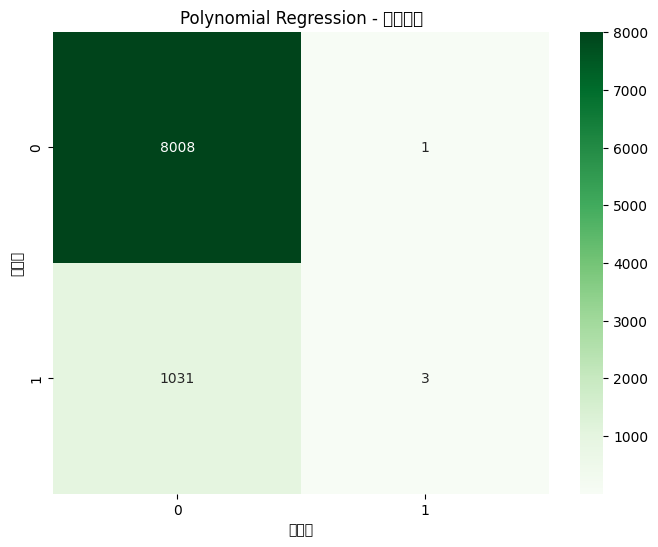

In [9]:
# 視覺化 Polynomial Regression 的混淆矩陣
plt.figure(figsize=(8, 6))
cm_poly = confusion_matrix(y_test, y_pred_poly)
sns.heatmap(cm_poly, annot=True, fmt='d', cmap='Greens', cbar=True)
plt.title('Polynomial Regression - 混淆矩陣')
plt.ylabel('實際值')
plt.xlabel('預測值')
plt.show()

In [8]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# 建立 Polynomial Regression 模型 (使用 2 次多項式)
# Pipeline 可以將多個步驟串接在一起
poly_model = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2)),  # 產生 2 次多項式特徵
    ('logistic_regression', LogisticRegression(max_iter=1000, random_state=100))
])

# 訓練模型
poly_model.fit(X_train, y_train)

# 預測
y_pred_poly = poly_model.predict(X_test)

# 計算準確率
poly_acc = accuracy_score(y_test, y_pred_poly)
print(f"Polynomial Regression 準確率: {poly_acc:.4f} ({poly_acc*100:.2f}%)")
print("\n分類報告:")
print(classification_report(y_test, y_pred_poly))

Polynomial Regression 準確率: 0.8859 (88.59%)

分類報告:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      8009
           1       0.75      0.00      0.01      1034

    accuracy                           0.89      9043
   macro avg       0.82      0.50      0.47      9043
weighted avg       0.87      0.89      0.83      9043



## 2. Polynomial Regression (多項式迴歸)

在分類問題中，我們使用 Polynomial Features 搭配 Logistic Regression

/Users/james_w/NCHU/jupyter_note/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23526 (\N{CJK UNIFIED IDEOGRAPH-5BE6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/james_w/NCHU/jupyter_note/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38555 (\N{CJK UNIFIED IDEOGRAPH-969B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/james_w/NCHU/jupyter_note/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/james_w/NCHU/jupyter_note/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/james_w/NCHU/jupyter_note/.venv/lib/python3.13/site-packa

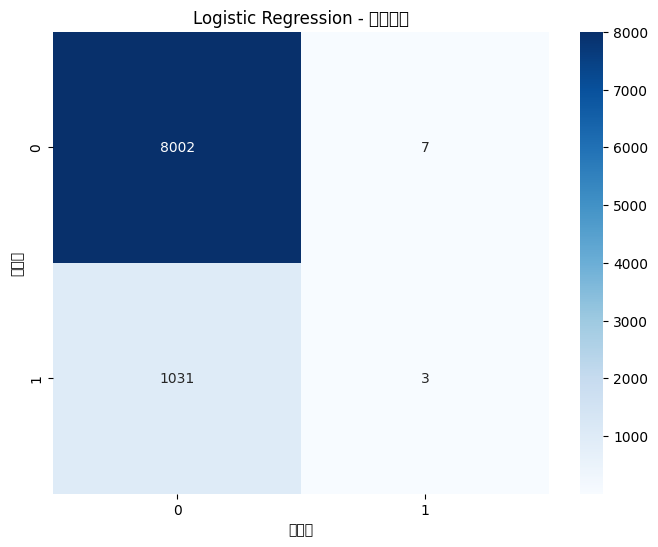

In [7]:
# 視覺化 Logistic Regression 的混淆矩陣
plt.figure(figsize=(8, 6))
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Logistic Regression - 混淆矩陣')
plt.ylabel('實際值')
plt.xlabel('預測值')
plt.show()

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 建立 Logistic Regression 模型
log_reg = LogisticRegression(max_iter=1000, random_state=100)

# 訓練模型
log_reg.fit(X_train, y_train)

# 預測
y_pred_log = log_reg.predict(X_test)

# 計算準確率
log_acc = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression 準確率: {log_acc:.4f} ({log_acc*100:.2f}%)")
print("\n分類報告:")
print(classification_report(y_test, y_pred_log))

Logistic Regression 準確率: 0.8852 (88.52%)

分類報告:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      8009
           1       0.30      0.00      0.01      1034

    accuracy                           0.89      9043
   macro avg       0.59      0.50      0.47      9043
weighted avg       0.82      0.89      0.83      9043

